# TMDB — Hiperparametre Tuning

`example.ipynb`'in ayrıştırılmış hâli — yalnızca veri hazırlığı, baseline eğitimi ve
Optuna hiperparametre tuning'ini içerir (Bölüm 0-4). Model değerlendirme, hibrit modeller,
SHAP, kalibrasyon ve feature mühendisliği deneyleri `modeling.ipynb`'e taşındı.

**Çıktı:** Bu notebook sonunda `tuned_models`, baseline `results`/`models` ve
`ensemble_candidates`'ı `artifacts/tuning_artifacts.joblib` dosyasına kaydeder — `modeling.ipynb` bunları buradan yükler,
tuning'i tekrar çalıştırmaz.

## 1 — Kütüphaneler

In [2]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / 'src').is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import importlib
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import src.mlflow_utils as mlu
import src.modeling, src.evaluation, src.tuning, src.reporting, src.automl
import src.eda_utils, src.preprocess_utils, src.validation, src.ensemble
for _mod in (src.modeling, src.evaluation, src.tuning, src.reporting, src.automl,
             src.eda_utils, src.preprocess_utils, src.validation, src.ensemble):
    importlib.reload(_mod)

from src.modeling import MAIN_METRIC, train_session, compare_models, quick_val_metrics
from src.evaluation import evaluate_test, bootstrap_ci, calibration_report
from src.tuning import tune_model, optimal_threshold_from_pr
from src.validation import walk_forward_cv
from src.ensemble import BlendingEnsemble
from src.reporting import generate_experiment_report
from src.eda_utils import temporal_entity_agg
from src.preprocess_utils import parse_json_list, multilabel_encode, topk_binary_encode, winsorize

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [4]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = '../data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 100
FEATURE_PREFIXES = ['genre_', 'kw_']
FEATURE_VERSION  = 'v13'  # 24 özellik: v12'ye ek is_english(%97 sabit,p=0.016) + kw_3d(%0.5 pozitif,p=0.025) drop edildi — Δ Test F2 = +0.0066 (gürültü azaldı)
SPLIT_MODE           = 'temporal'   # 'temporal' | 'random'
SAMPLE_WEIGHT_MODE   = None          # None | 'linear' | 'exponential' — ADVBK-80 dağılım kayması testinden sonra seçilecek

BASE_FEATURES = [
    # Bütçe & Prodüksiyon
    'budget_adjusted', 'runtime',
    'num_companies',
    'is_major_studio', 'is_us_production',
    # Pazarlama
    'has_homepage',
    # Tür & Franchise
    'num_genres', 'is_franchise',
    # Takvim
    'is_summer', 'is_holiday',
    # Yönetmen & Oyuncu geçmişi (temporal safe)
    'director_film_count', 'director_collab_count',
    'actor_hist_roi',
    # Yapım şirketi geçmişi (temporal safe)
    'company_hist_roi',
    # Aylık rekabet & franchise yoğunluğu (ADVBK-82)
    'monthly_franchise_density',
]
# ──────────────────────────────────────────────────────────────

### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (30 adet) — v9

| Grup | Sayı | Özellikler |
|------|------|-----------|
| Sayısal / meta | 9 | `budget_adjusted`, `runtime`, `num_companies`, `num_genres`, `director_film_count`, `director_collab_count`, `director_hist_roi`, `actor_hist_roi`, `company_hist_roi` |
| Binary — yapısal | 7 | `is_major_studio`, `is_english`, `is_us_production`, `has_homepage`, `is_summer`, `is_holiday`, `is_franchise` |
| Temporal geçmiş | 2 | `director_hist_vote_avg`, `actor_hist_vote_avg` |
| Binary — tür | 9 | `genre_Action`, `genre_Adventure`, `genre_Animation`, `genre_Documentary`, `genre_Drama`, `genre_Family`, `genre_Fantasy`, `genre_Horror`, `genre_Science Fiction` |
| Binary — keyword | 3 | `kw_3d`, `kw_sequel`, `kw_independent_film` |

**Notlar:**
- `director_film_count` / `director_collab_count` / `director_hist_roi` / `actor_hist_roi` / `company_hist_roi` — temporal safe: her film için yalnızca `release_date` öncesi filmler kullanılır
- `budget_adjusted` — CPI-adjusted bütçe (ADVBK-70). `relative_budget_score` v10'da test edildi: LogReg'de zıt yön + test F2 -0.009 → drop edildi (ADVBK-75)
- `has_director_history`, `has_actor_history`, `has_company_history` v11'de test edildi: LGBM top-20 dışı, `has_actor_history` LogReg'de negatif yön, test F2 -0.007 → drop edildi (ADVBK-72)
- `is_summer` = Haziran–Ağustos vizyonu; `is_holiday` = Kasım–Aralık vizyonu

#### Çıkarılan Özellikler

| Özellik | Gerekçe |
|---------|--------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra TMDB'de oluşur |
| `has_postcredit` | Post-release — filmin izlenmesini gerektirir |
| `budget_log` | `budget_adjusted` zaten mevcut; log dönüşümü tree modeller için gereksiz |
| `budget_per_minute` | Multikolinearite: `budget_adjusted` ile r=0.969 |
| `relative_budget_score` | v10'da test edildi — LogReg'de `budget_adjusted` ile zıt yön (redundant), test F2 -0.009 (ADVBK-75) |
| `has_director_history`, `has_actor_history`, `has_company_history` | v11'de test edildi — LGBM top-20 dışı, `has_actor_history` LogReg negatif, test F2 -0.007 (ADVBK-72) |
| `tagline_length`, `overview_length`, `num_countries`, `num_languages` | Bonferroni anlamsız (p > 0.0010) |
| `kw_based_on_novel`, `kw_woman_director`, `kw_biography`, `kw_musical` | Bonferroni anlamsız (p > 0.0010) |
| 10 genre özelliği | Bonferroni anlamsız: `genre_Romance`, `genre_Crime`, `genre_History`, `genre_Western`, `genre_Mystery`, `genre_Comedy`, `genre_War`, `genre_Foreign`, `genre_Thriller`, `genre_Music` |
| `kw_aftercreditsstinger`, `kw_duringcreditsstinger` | Post-release — kullanıcılar izledikten sonra etiketler |
| `kw_murder`, `kw_dystopia`, vb. | Post-release — kullanıcıların film izledikten sonra eklediği içerik etiketleri |

### Veri Hazırlama *(dokunma)*

In [5]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem

# MLflow kullanımı opsiyonel: True yaparsan docker container'daki mlflow sunucusuna
# (MLFLOW_TRACKING_URI env değişkeni veya http://localhost:5000) bağlanılır ve tüm
# run'lar/model kayıtları oraya loglanır — tek kayıt kaynağı budur. False (varsayılan)
# iken hiçbir mlflow ağ çağrısı yapılmaz; notebook mlflow sunucusu kapalıyken de çalışır.
USE_MLFLOW = False
mlu.USE_MLFLOW = USE_MLFLOW

if USE_MLFLOW:
    MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
    mlflow.set_tracking_uri(MLFLOW_URI)
else:
    print("○ MLflow devre dışı (USE_MLFLOW=False) — hiçbir run/model mlflow'a kaydedilmeyecek")

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols  # release_year intentionally excluded

df_model = df[FEATURES + [TARGET]]
X        = df_model[FEATURES]
y        = df_model[TARGET]

if SPLIT_MODE == 'temporal' and 'release_year' in df.columns:
    # Temporal split: ≤2013 train / 2014–2015 val / ≥2016 test  (~90%/8%/2%)
    # ADVBK-96: train cutoff 2009→2013 — model now sees franchise-era (2010–2013) dynamics
    TRAIN_CUTOFF = 2013
    VAL_CUTOFF   = 2015
    yr = df['release_year']
    mask_train = yr <= TRAIN_CUTOFF
    mask_val   = (yr > TRAIN_CUTOFF) & (yr <= VAL_CUTOFF)
    mask_test  = yr > VAL_CUTOFF
    X_train = X[mask_train].reset_index(drop=True)
    y_train = y[mask_train].reset_index(drop=True)
    X_val   = X[mask_val].reset_index(drop=True)
    y_val   = y[mask_val].reset_index(drop=True)
    X_test  = X[mask_test].reset_index(drop=True)
    y_test  = y[mask_test].reset_index(drop=True)
    split_desc = f'temporal (≤{TRAIN_CUTOFF} / {TRAIN_CUTOFF+1}–{VAL_CUTOFF} / ≥{VAL_CUTOFF+1})'
elif TASK_TYPE == 'timeseries':
    n = len(X)
    X_train = X.iloc[:int(n * 0.70)]
    X_val   = X.iloc[int(n * 0.70):int(n * 0.85)]
    X_test  = X.iloc[int(n * 0.85):]
    y_train = y.iloc[:int(n * 0.70)]
    y_val   = y.iloc[int(n * 0.70):int(n * 0.85)]
    y_test  = y.iloc[int(n * 0.85):]
    split_desc = 'timeseries (positional 70/15/15)'
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    # 3-way split: 70 / 15 / 15
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=stratify, random_state=RANDOM_STATE,
    )
    val_frac = 0.15 / 0.85  # ~17.6% of temp → ~15% of total
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac,
        stratify=y_temp if TASK_TYPE in ('binary', 'multiclass') else None,
        random_state=RANDOM_STATE,
    )
    split_desc = 'random stratified (70/15/15)'

# Hist features NaN imputation — train medyanı ile (leakage-free)
_hist_cols = [c for c in FEATURES if 'hist' in c]
if _hist_cols:
    _medians = X_train[_hist_cols].median()
    X_train = X_train.copy()
    X_val   = X_val.copy()
    X_test  = X_test.copy()
    X_train[_hist_cols] = X_train[_hist_cols].fillna(_medians)
    X_val[_hist_cols]   = X_val[_hist_cols].fillna(_medians)
    X_test[_hist_cols]  = X_test[_hist_cols].fillna(_medians)
    print(f'NaN imputation: {_hist_cols} → train medyanı kullanıldı')

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Split    : {split_desc}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}  ({len(X_train)/len(df_model)*100:.0f}%)  |  hit: %{y_train.mean()*100:.1f}')
print(f'Val      : {len(X_val):,}  ({len(X_val)/len(df_model)*100:.0f}%)  |  hit: %{y_val.mean()*100:.1f}')
print(f'Test     : {len(X_test):,}  ({len(X_test)/len(df_model)*100:.0f}%)  |  hit: %{y_test.mean()*100:.1f}')
print(f'Özellik  : {len(FEATURES)}')

○ MLflow devre dışı (USE_MLFLOW=False) — hiçbir run/model mlflow'a kaydedilmeyecek
NaN imputation: ['actor_hist_roi', 'company_hist_roi'] → train medyanı kullanıldı
Dataset  : ../data/tmdb_model.csv
Task     : binary
Split    : temporal (≤2013 / 2014–2015 / ≥2016)
Toplam   : 3,226  |  hit oranı: %36.5
Train    : 2,899  (90%)  |  hit: %35.7
Val      : 255  (8%)  |  hit: %41.6
Test     : 72  (2%)  |  hit: %47.2
Özellik  : 26


### Hit Eşiği Gerekçesi — $100M (2010 dolar)

**Sektör ekonomisi argümanı:** Sinema salonları gişe hasılatının ~%50'sini alır;
P&A (prints & advertising) maliyeti genellikle prodüksiyon bütçesine yakındır.
Veri setindeki medyan bütçeli film için başabaş hesabı:

| Kalem | Değer |
|---|---|
| Medyan prodüksiyon bütçesi (2010$) | ~$28.6M |
| P&A maliyeti (≈ prodüksiyon bütçesi) | ~$28.6M |
| Toplam maliyet | ~$57M |
| Sinema salonu payı | %50 |
| Başabaş gişe hasılatı | **~$114M ≈ $100M** |

> Hit/Miss ayrımı ekonomik olarak **kâr/zarar sınırını** temsil eder.
> Aşağıdaki grafik bütçe dağılımını, başabaş eşiğini ve Hit oranını birlikte göstermektedir.


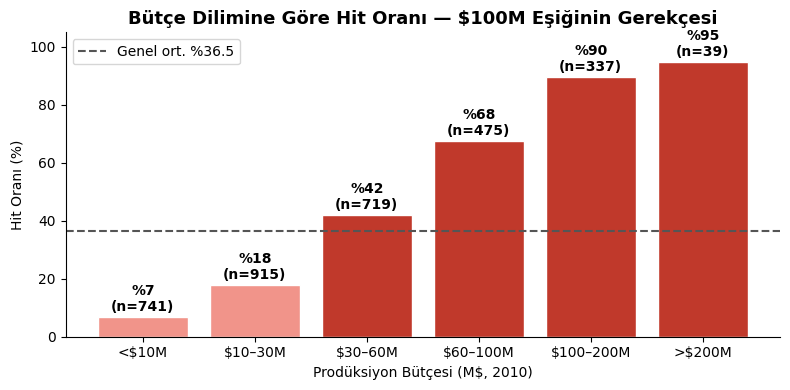

In [6]:
bins_   = [0, 10, 30, 60, 100, 200, 400]
labels_ = ["<$10M", "$10–30M", "$30–60M", "$60–100M", "$100–200M", ">$200M"]
df["_budget_bin"] = pd.cut(df["budget_adjusted"] / 1e6, bins=bins_, labels=labels_)
hit_by_bin = df.groupby("_budget_bin", observed=True)["hit"].agg(["mean", "count"])
baseline_  = df["hit"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
colors_ = ["#f1948a" if v < baseline_ else "#c0392b" for v in hit_by_bin["mean"]]
bars_ = ax.bar(hit_by_bin.index, hit_by_bin["mean"] * 100, color=colors_, edgecolor="white")
ax.axhline(baseline_ * 100, color="#555555", lw=1.5, ls="--",
           label=f"Genel ort. %{baseline_*100:.1f}")
for bar, (_, row) in zip(bars_, hit_by_bin.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"%{row['mean']*100:.0f}\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xlabel("Prodüksiyon Bütçesi (M$, 2010)")
ax.set_ylabel("Hit Oranı (%)")
ax.set_title("Bütçe Dilimine Göre Hit Oranı — $100M Eşiğinin Gerekçesi",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
df.drop(columns=["_budget_bin"], inplace=True)
plt.tight_layout()
plt.show()


## 3 — Baseline Eğitimi

○ MLflow devre dışı (USE_MLFLOW=False) — run'lar kaydedilmeyecek
Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260811_2317  |  task: binary


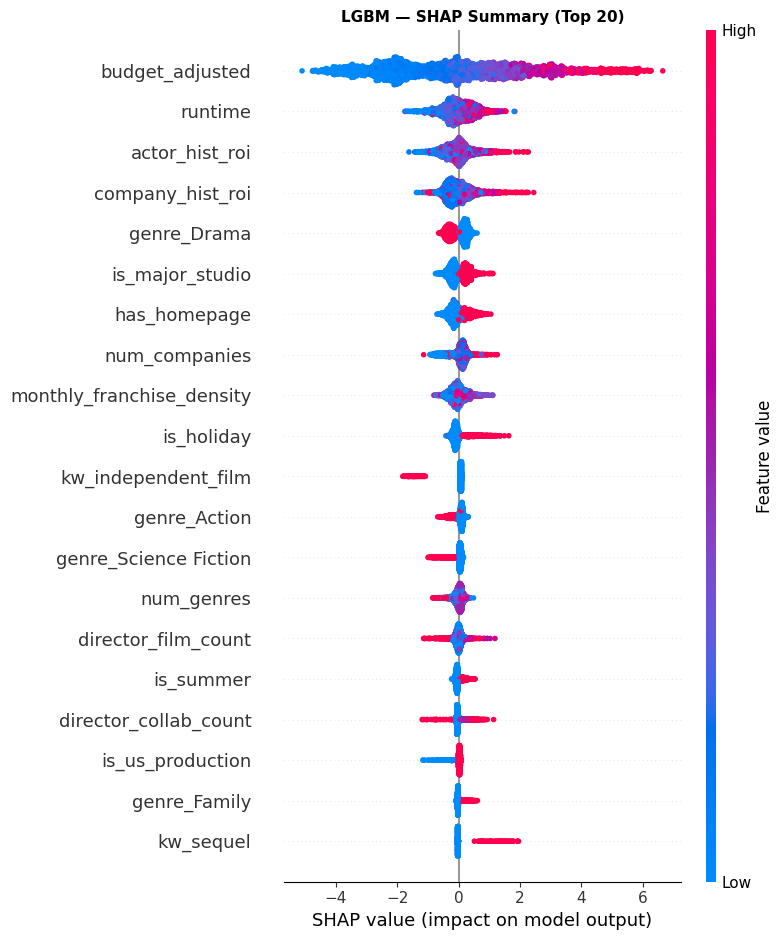

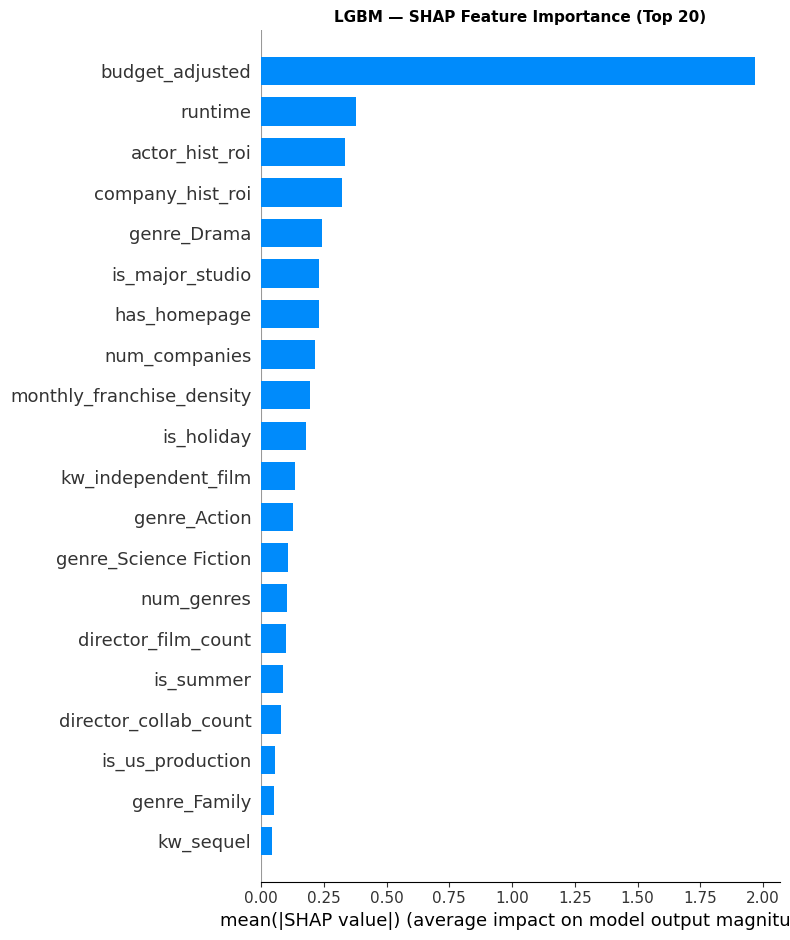

  ✓ baseline_lgbm_20260811_2317                        train=1.000  val=0.647  gap=+0.352


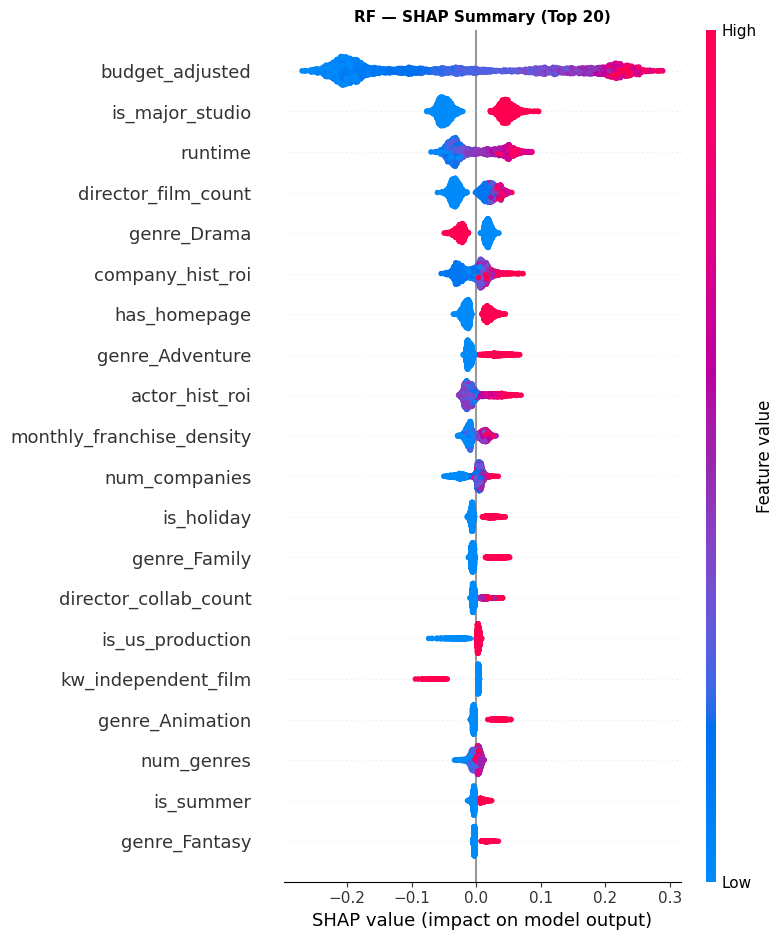

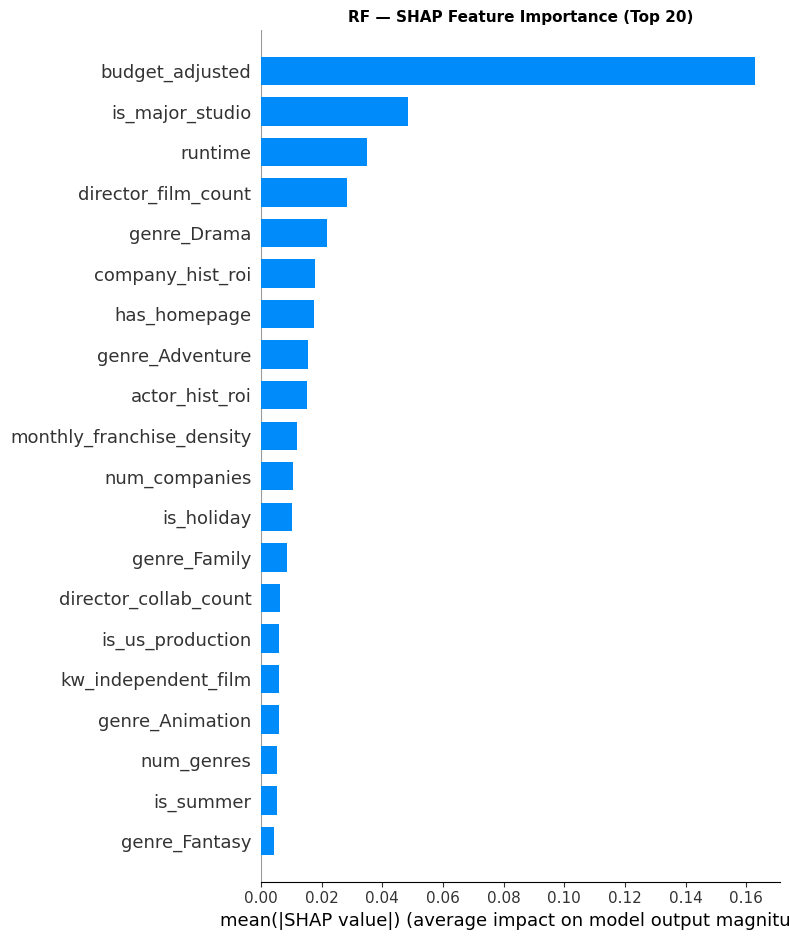

  ✓ baseline_rf_20260811_2317                          train=0.801  val=0.727  gap=+0.074


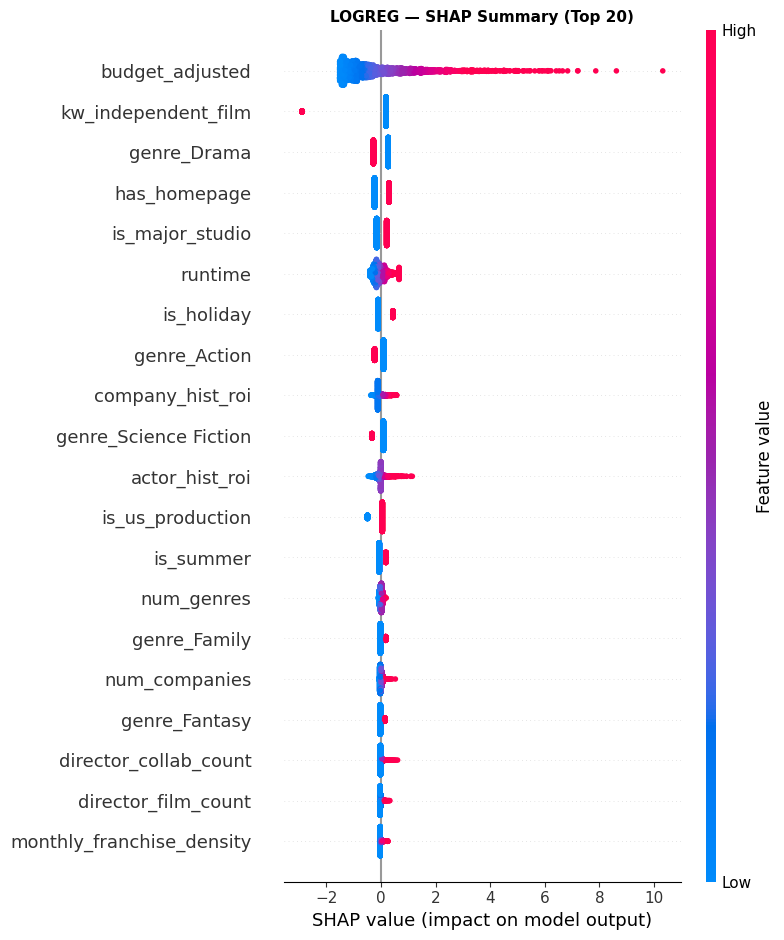

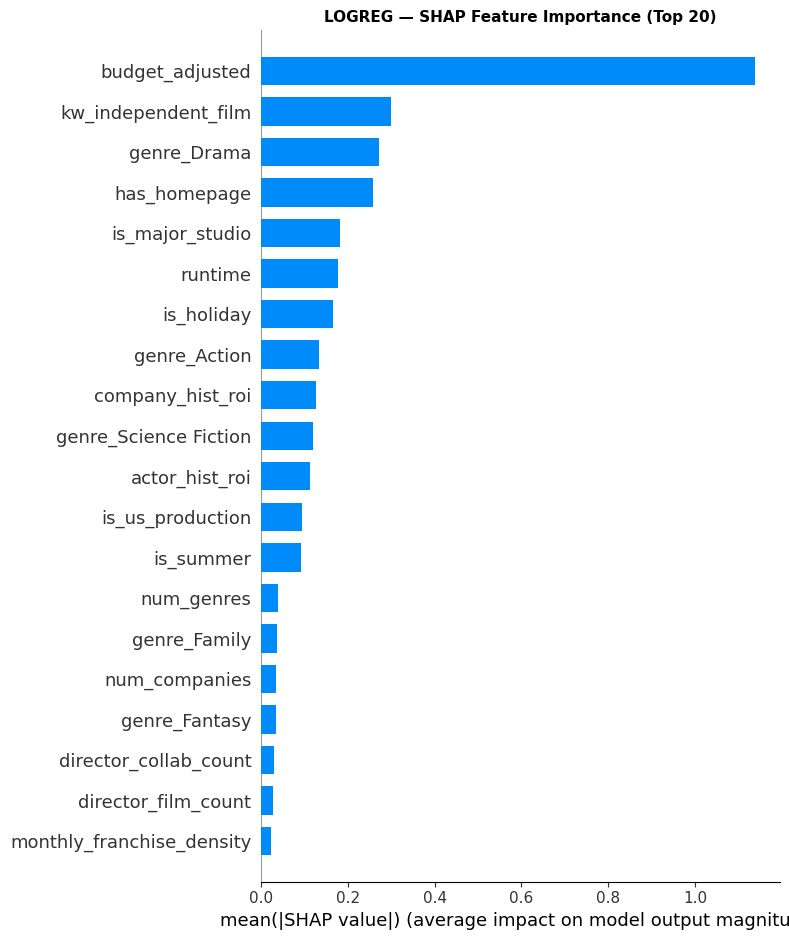

  ✓ baseline_logreg_20260811_2317                      train=0.726  val=0.718  gap=+0.009
  ✓ baseline_xgb_20260811_2318                         train=0.788  val=0.653  gap=+0.134
  ✓ baseline_catboost_20260811_2318                    train=0.846  val=0.735  gap=+0.111

✓ Oturum tamamlandı


In [7]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
    'xgb': lambda ir: XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        min_child_weight=10, reg_alpha=1.0, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=ir, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=1, verbosity=0,
    ),
    'catboost': lambda ir: CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=4,
        l2_leaf_reg=3.0, auto_class_weights='Balanced',
        random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    ),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,F2,PRECISION,RECALL,AVG_PREC
Model,,,,,,
lgbm,0.831,0.666,0.647,0.702,0.636,0.750
rf,0.852,0.704,0.727,0.668,0.744,0.781
logreg,0.853,0.704,0.718,0.683,0.728,0.785
xgb,0.844,0.682,0.653,0.738,0.636,0.770
catboost,0.853,0.709,0.735,0.671,0.753,0.785



🏆 En iyi model: catboost  (f2=0.735)


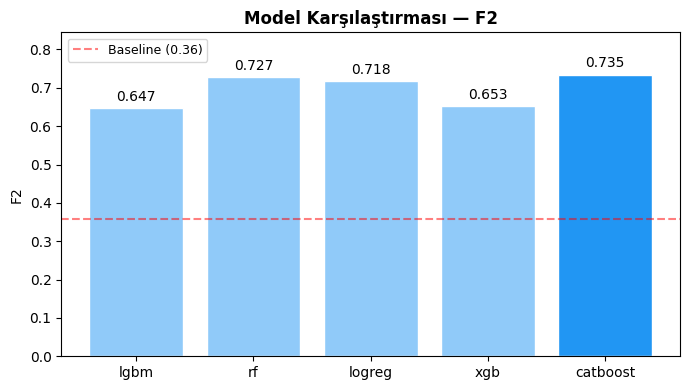


=== Overfitting / Underfitting Analizi ===


,Train F2,Val F2,Gap (Train−Val)
Model,,,
lgbm,1.000,0.647,0.352
rf,0.801,0.727,0.074
logreg,0.726,0.718,0.009
xgb,0.788,0.653,0.134
catboost,0.846,0.735,0.111


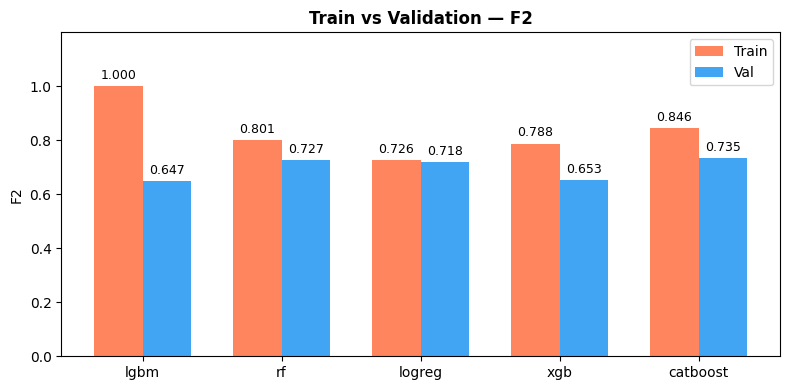

  ⚠️  lgbm: ciddi overfit (gap=0.352 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg', 'xgb', 'catboost'] — en iyi: catboost


In [8]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [9]:
from src.automl import tune_all_models

ir = (y_train == 0).sum() / (y_train == 1).sum()

def lgbm_temporal_fn(trial):
    """Temporal split için yüksek regularization LGBM search space."""
    from lightgbm import LGBMClassifier
    max_depth = trial.suggest_int('max_depth', 3, 5)
    return LGBMClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        max_depth         = max_depth,
        num_leaves        = trial.suggest_int('num_leaves', 8, 2**max_depth),
        min_child_samples = trial.suggest_int('min_child_samples', 30, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 50.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 0.8),
        scale_pos_weight  = ir,
        random_state      = RANDOM_STATE,
        verbose           = -1,
        n_jobs            = 1,
    )

def xgb_temporal_fn(trial):
    """Temporal split icin yuksek regularization XGBoost search space."""
    from xgboost import XGBClassifier
    return XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 5),
        min_child_weight  = trial.suggest_int('min_child_weight', 10, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 50.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 0.8),
        scale_pos_weight  = ir,
        eval_metric       = 'logloss',
        random_state      = RANDOM_STATE,
        n_jobs            = 1,
        verbosity         = 0,
    )

def catboost_temporal_fn(trial):
    """Temporal split icin yuksek regularization CatBoost search space."""
    from catboost import CatBoostClassifier
    return CatBoostClassifier(
        iterations        = trial.suggest_int('iterations', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        depth             = trial.suggest_int('depth', 3, 5),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1.0, 50.0, log=True),
        random_strength   = trial.suggest_float('random_strength', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        auto_class_weights = 'Balanced',
        random_seed       = RANDOM_STATE,
        verbose           = 0,
        allow_writing_files = False,
    )

best_model, best, tuned_models, ensemble_candidates = tune_all_models(
    results           = results,
    X                 = X_train,
    y                 = y_train,
    task_type         = TASK_TYPE,
    n_trials          = N_TRIALS,
    max_gap           = 0.10,
    model_fn_map      = {'lgbm': lgbm_temporal_fn, 'xgb': xgb_temporal_fn, 'catboost': catboost_temporal_fn},
    X_val             = X_val,
    y_val             = y_val,
    jaccard_threshold = 0.60,
    feature_version   = FEATURE_VERSION,
)

if ensemble_candidates:
    print(f"\nEnsemble adayları: {list(ensemble_candidates.keys())}")


── Tuning: rf  (baseline=0.7274  min_improvement=0.0116) ──
Optuna başlıyor — model: rf  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.7274
  Tuned     f2: 0.7431
  İyileşme : +0.0157

  En iyi parametreler:
    n_estimators: 234
    max_depth: 20
    min_samples_leaf: 28
    max_features: log2
  Train-val gap: 0.0286  (✓ eşik altı)
○ MLflow devre dışı (USE_MLFLOW=False) — tuning sonuçları kaydedilmedi

✓ best_model güncellendi — tuned rf
  ✓ rf: aday  (0.7431)

── Tuning: logreg  (baseline=0.7177  min_improvement=0.0280) ──
Optuna başlıyor — model: logreg  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.7177
  Tuned     f2: 0.7204
  İyileşme : +0.0027

  En iyi parametreler:
    C: 0.46935394108828166
  Train-val gap: 0.0073  (✓ eşik altı)
○ MLflow devre dışı (USE_MLFLOW=False) — tuning sonuçları kaydedilmedi

✓ best_model güncellendi — tuned logreg
  — logreg: iyileşme yetersiz (+0.0027 < 0.0280) — elendi

── Tuning: xgb  (baseline=0.6533  min_improvement=0.0293) ──
Optuna başlıyor — model: xgb  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


...


✓ Tuning tamamlandı
  Baseline  f2: 0.6533
  Tuned     f2: 0.7460
  İyileşme : +0.0927

  En iyi parametreler:
    n_estimators: 999
    learning_rate: 0.029794195209756846
    max_depth: 3
    min_child_weight: 17
    reg_alpha: 14.185818368576928
    reg_lambda: 6.83259376262111
    subsample: 0.7527389925996387
    colsample_bytree: 0.6300665445811728
  Train-val gap: 0.0386  (✓ eşik altı)
○ MLflow devre dışı (USE_MLFLOW=False) — tuning sonuçları kaydedilmedi

✓ best_model güncellendi — tuned xgb
  ✓ xgb: aday  (0.7460)

── Tuning: catboost  (baseline=0.7346  min_improvement=0.0265) ──
Optuna başlıyor — model: catboost  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.7346
  Tuned     f2: 0.7476
  İyileşme : +0.0131

  En iyi parametreler:
    iterations: 605
    learning_rate: 0.021801744782730864
    depth: 3
    l2_leaf_reg: 9.204453057468369
    random_strength: 2.900465915241133
    bagging_temperature: 0.07675303149379781
    subsample: 0.5532542217416743
  Train-val gap: 0.0305  (✓ eşik altı)
○ MLflow devre dışı (USE_MLFLOW=False) — tuning sonuçları kaydedilmedi

✓ best_model güncellendi — tuned catboost
  — catboost: iyileşme yetersiz (+0.0130 < 0.0265) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.6474
  Tuned     f2: 0.7461
  İyileşme : +0.0987

  En iyi parametreler:
    max_depth: 4
    n_estimators: 876
    learning_rate: 0.017067377776092286
    num_leaves: 15
    min_child_samples: 96
    reg_alpha: 18.797868706710577
    reg_lambda: 3.2861647438549575
    subsample: 0.6155453653526668
    colsample_bytree: 0.501871972245118
  Train-val gap: 0.0201  (✓ eşik altı)
○ MLflow devre dışı (USE_MLFLOW=False) — tuning sonuçları kaydedilmedi

✓ best_model güncellendi — tuned lgbm
  — lgbm: recovery tamamlandı (0.7461 ≤ 0.7476) — best model değişmedi

✓ tune_all_models tamamlandı — best: catboost  (f2=0.7476)

── Ensemble Aday Analizi (Jaccard eşik=0.6) ──
  catboost ↔ rf: Jaccard=0.73 → atlandı (>0.6)
  catboost ↔ logreg: Jaccard=0.67 → atlandı (>0.6)
  catboost ↔ xgb: Jaccard=0.78 → atlandı (>0.6)
  catboost ↔ lgbm: Jaccard=0.76 → atlandı (>0.6)
  Yeterli çeşitlilik yok — ensemble önerilmiyor.


## 5 — Tuning Sonuçlarını Kaydet

`modeling.ipynb`'in yeniden tuning çalıştırmadan devam edebilmesi için `tuned_models` ve ilgili nesneler diske yazılır.

In [10]:
import joblib
from pathlib import Path

_artifact_path = Path("artifacts/tuning_artifacts.joblib")
_artifact_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "tuned_models": tuned_models,
        "ensemble_candidates": ensemble_candidates,
        "results": results,
        "models": models,
        "best": best,
        "feature_version": FEATURE_VERSION,
    },
    _artifact_path,
)
print(f"✓ Kaydedildi → {_artifact_path}  (modeling.ipynb bu dosyayı yükleyecek)")

✓ Kaydedildi → artifacts/tuning_artifacts.joblib  (modeling.ipynb bu dosyayı yükleyecek)
